# Clustering Metrics : Practice & Experiments

**Authored by Alexandre Mathias DONNAT, Sr**

Here we will use and interpret clustering metrics on the Iris Dataset

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
from sklearn import datasets
from sklearn.cluster import KMeans

In [3]:
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
from sklearn.metrics.cluster import contingency_matrix

## Data

In [4]:
iris = datasets.load_iris()
X = iris.data  
y = iris.target
feature_names = iris.feature_names
label_names = iris.target_names

In [5]:
feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [6]:
print(label_names)

['setosa' 'versicolor' 'virginica']


In [7]:
def show_data(X, y, features=[0, 1], feature_names=feature_names):
    '''Display the samples in 2D'''
    plt.figure(figsize=(5,5))
    for label in set(y):
        plt.scatter(X[y == label, features[0]], X[y == label, features[1]])
    plt.xlabel(feature_names[features[0]])
    plt.ylabel(feature_names[features[1]])
    plt.show()

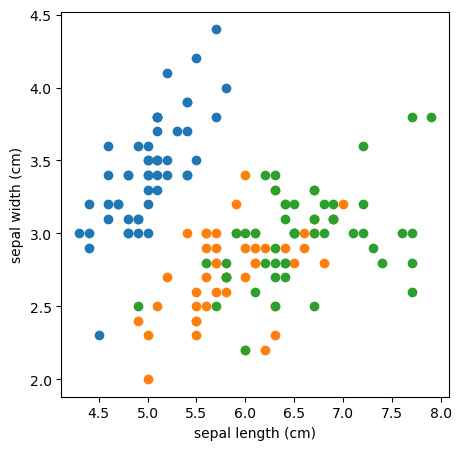

In [8]:
show_data(X, y, [0, 1])

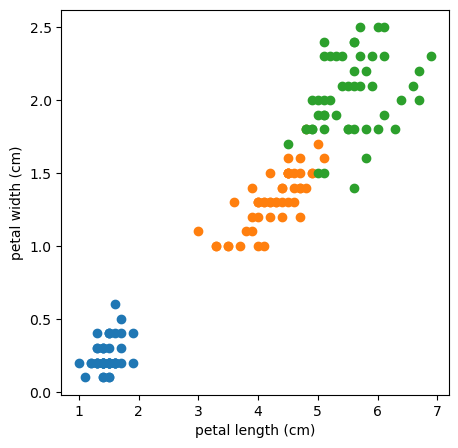

In [9]:
show_data(X, y, [2, 3])

## K-means

Let's apply k-means and display the clusters.

In [20]:
km = KMeans(n_clusters=3, n_init=10)
labels = km.fit_predict(X)

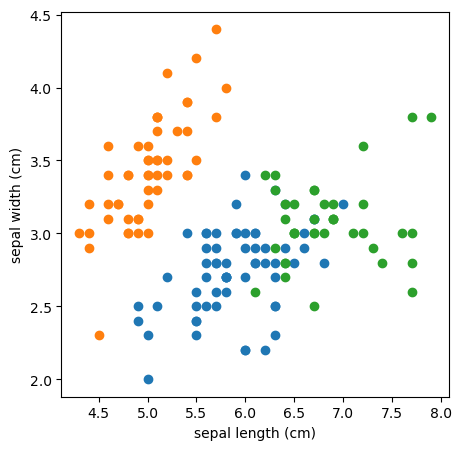

In [21]:
show_data(X, labels, [0, 1])

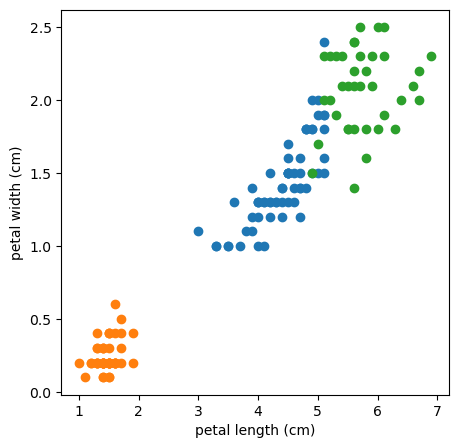

In [22]:
show_data(X, labels, [2, 3])

## Silhouette

We first try to assess the quality of the clustering using the silhouette score. Here we do not use the ground-truth labels.

## To do

* Compute the silhouette of each sample.
* What are the 3 samples of lowest silhouette? What are their clusters?
* Display the silhouette distribution of each cluster using Seaborn (check ``sns.kdeplot``).
* What are the worst clusters in terms of silhouette?
* Compute the average silhouette when the number of clusters grows from 2 to 6.<br> 
What is the optimal number of clusters in terms of average silhouette?

In [50]:
silhouette_avg = silhouette_score(X, labels)
sample_silhouette_values = silhouette_samples(X, labels)
min_n = sample_silhouette_values.argsort()

In [52]:
print(labels[min_n[:3]])

[0 0 2]


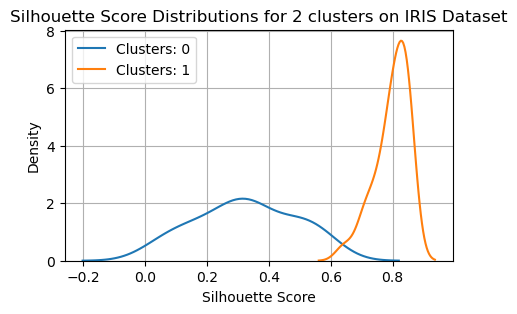

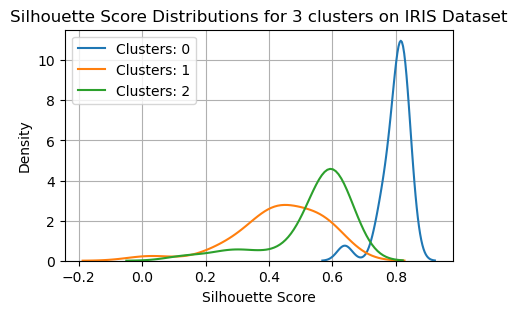

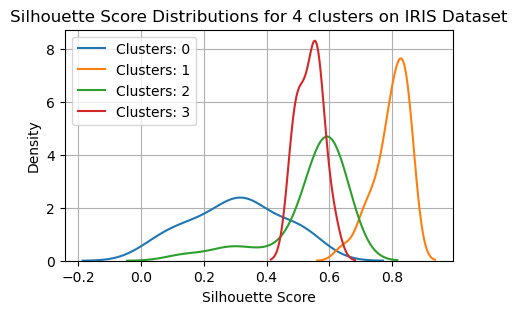

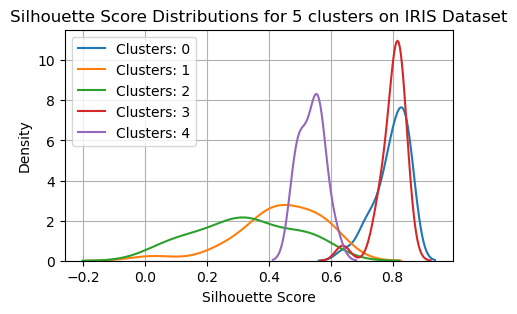

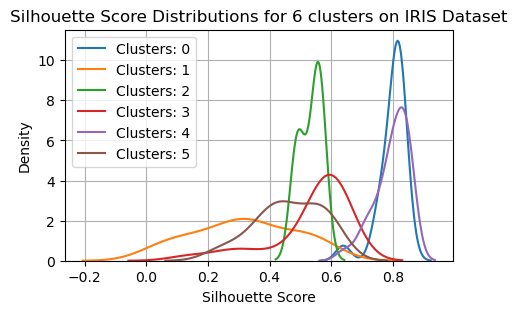

In [65]:
for n_clusters in range(2,7):
    km = KMeans(n_clusters=n_clusters, n_init=10)
    labels = kmeans.fit_predict(X)
    silhouette_vals = silhouette_samples(X, labels)
    plt.figure(figsize=(5, 3))
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
        sns.kdeplot(ith_cluster_silhouette_values, label=f'Clusters: {i}')

    plt.xlabel("Silhouette Score")
    plt.ylabel("Density")
    plt.title(f"Silhouette Score Distributions for {n_clusters} clusters on IRIS Dataset")
    plt.legend()
    plt.grid(True)
    plt.show()


For n_clusters = 2 The average silhouette_score is : 0.6810461692117462


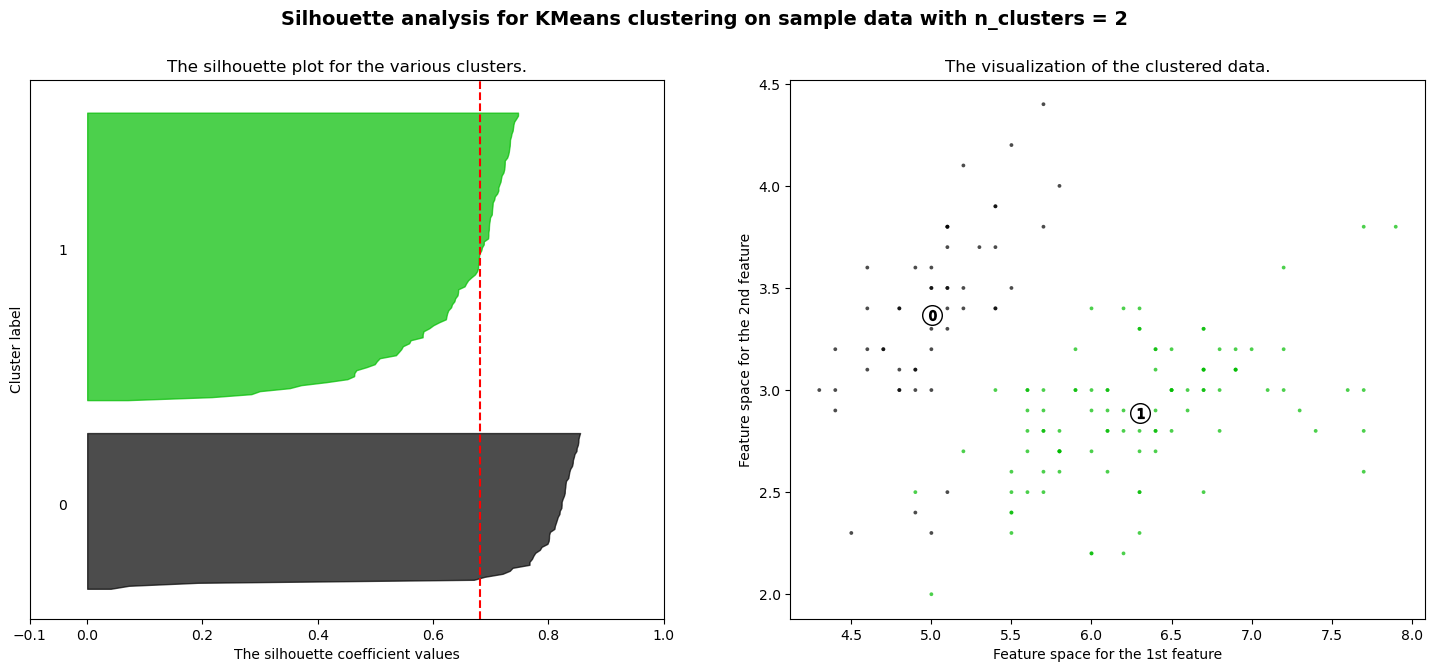

For n_clusters = 3 The average silhouette_score is : 0.5528190123564095


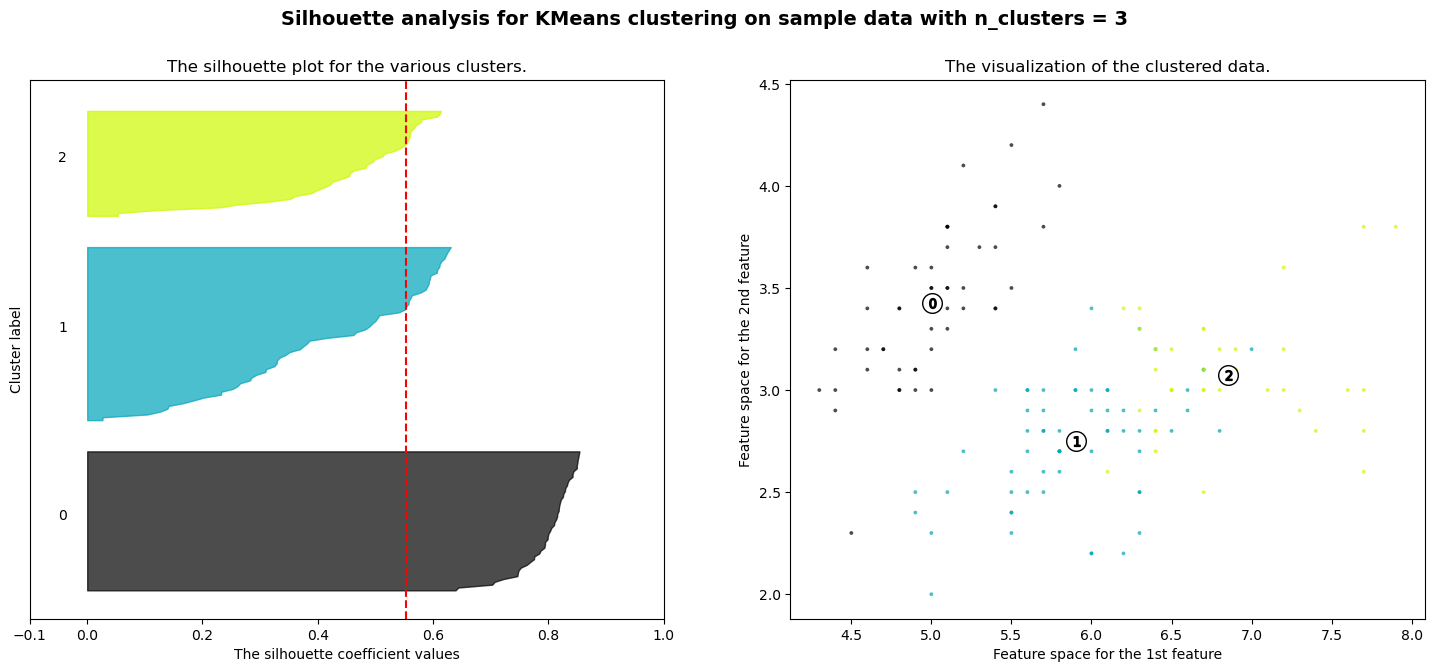

For n_clusters = 4 The average silhouette_score is : 0.4974551890173751


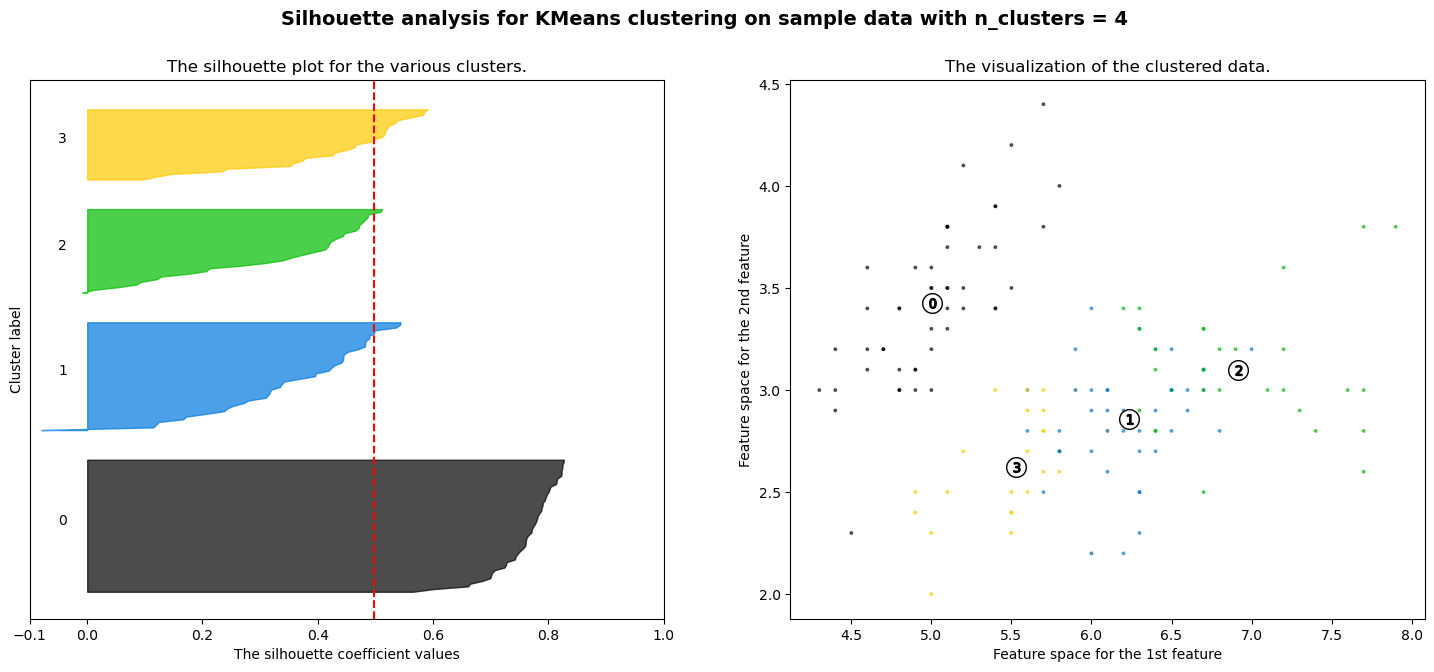

For n_clusters = 5 The average silhouette_score is : 0.48874888709310566


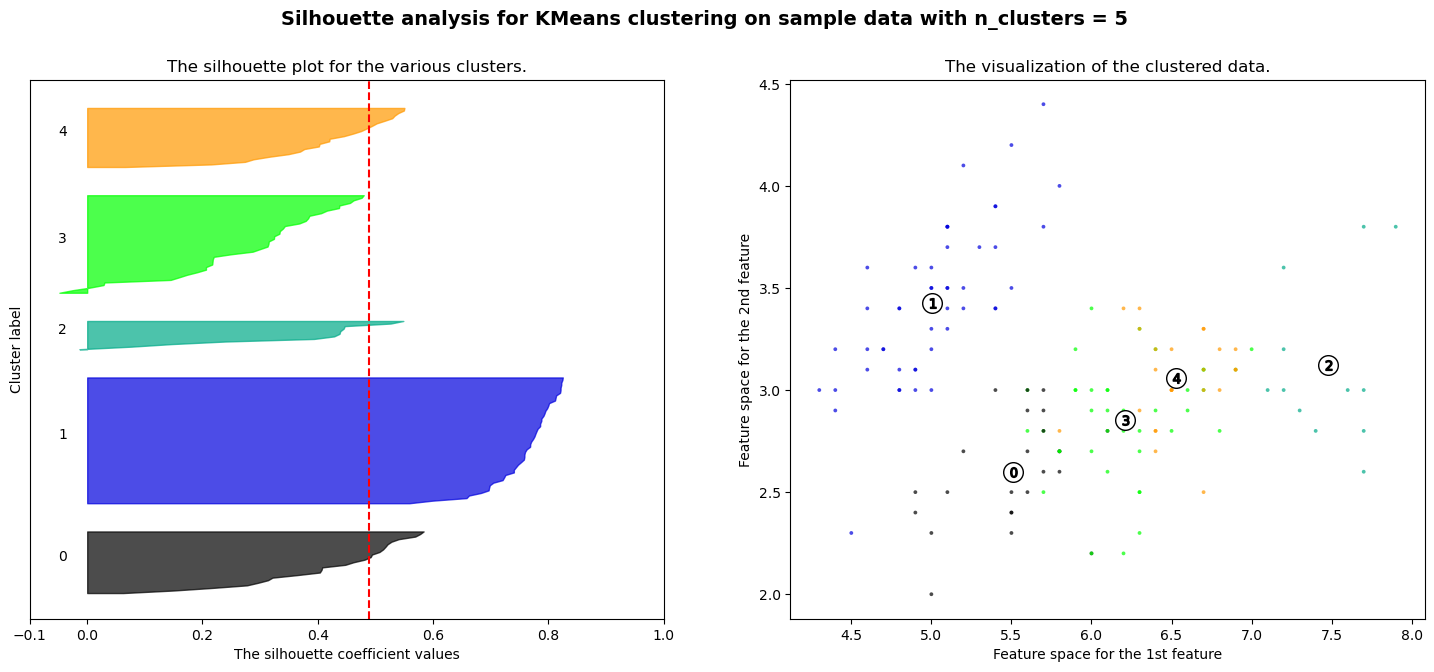

For n_clusters = 6 The average silhouette_score is : 0.36483400396700255


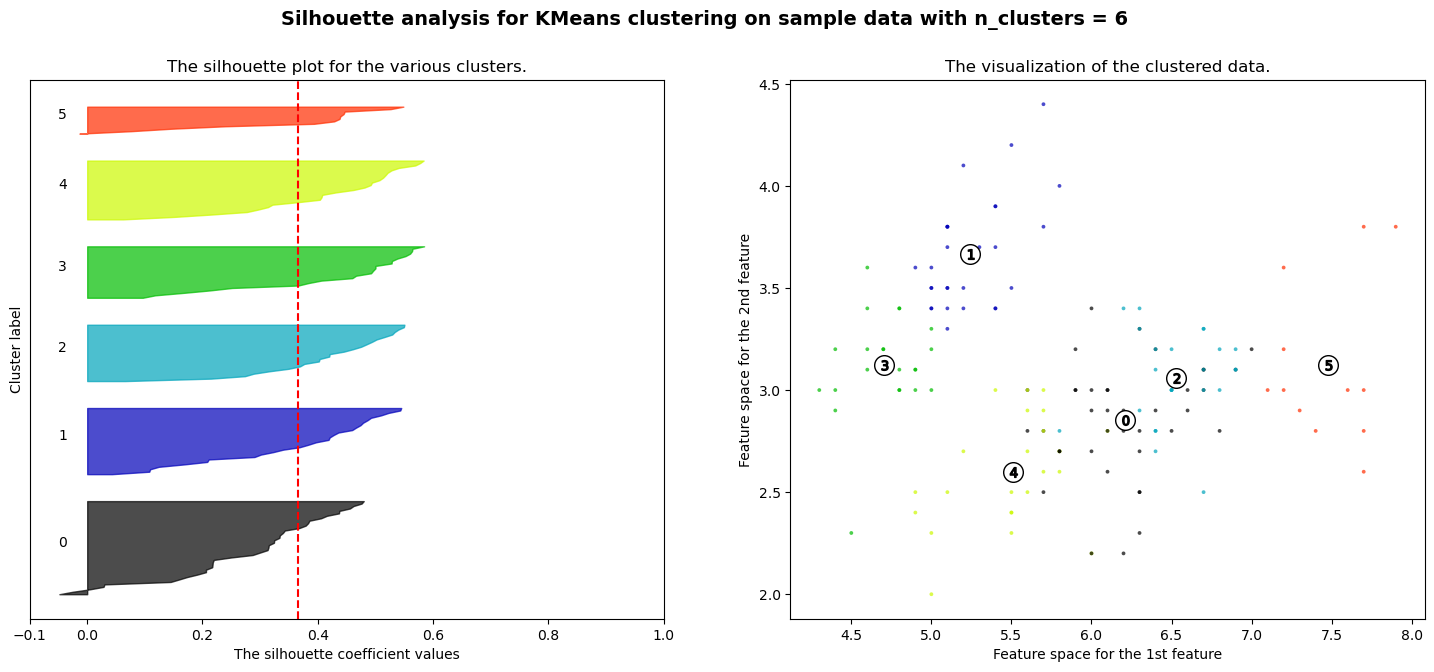

In [19]:
import matplotlib.cm as cm

for n_clusters in range(2,7):
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot 
    # The silhouette coefficient can range from -1, 1 but in this example all lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    km = KMeans(n_clusters=n_clusters, n_init=10)
    labels = km.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed clusters
    silhouette_avg = silhouette_score(X, labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(labels.astype(float) / n_clusters)
    ax2.scatter(
        X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = km.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(centers[:, 0],centers[:, 1],marker="o",c="white",alpha=1,s=200,edgecolor="k")

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

    plt.show()

## Contingency matrix

We now use the ground-truth labels. First, we compute and display the contingency matrix.

In [13]:
n_clusters = 3
km = KMeans(n_clusters, n_init=10)
labels = km.fit_predict(X)

In [14]:
contingency = contingency_matrix(y, labels)

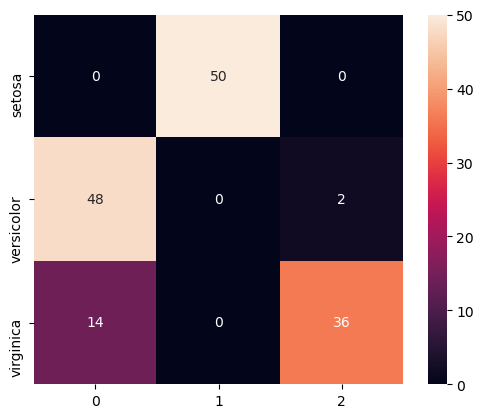

In [15]:
sns.heatmap(contingency, annot=True, square=True, xticklabels=np.arange(n_clusters), yticklabels=label_names);

## Metrics

Second, we use the metrics (Average F1 score, ARI and AMI) to find the optimal number of clusters.

## To do

* Plot the ARI and AMI scores with respect to the number of clusters.
* What is the optimal number of clusters?

In [56]:
adjusted_rand_score(y, labels)
adjusted_mutual_info_score(y, labels)

0.7551191675800486

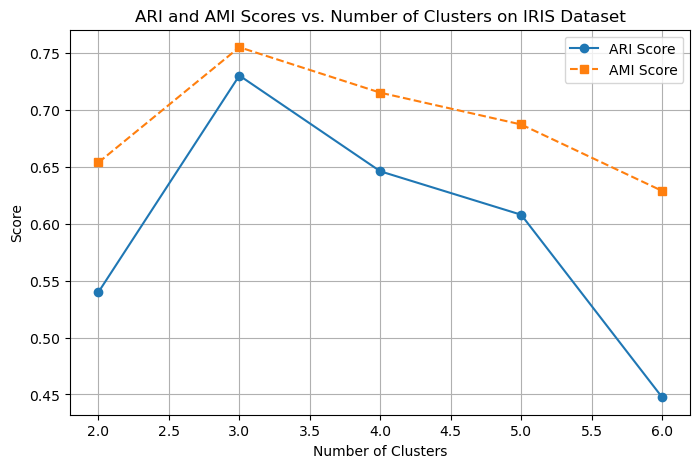

In [58]:
ari_scores = []
ami_scores = []

# Perform clustering and compute ARI & AMI scores
for n_clusters in range(2,7):
    kmeans = KMeans(n_clusters=n_clusters, n_init=10)
    labels = kmeans.fit_predict(X)
    
    ari = adjusted_rand_score(y, labels)
    ami = adjusted_mutual_info_score(y, labels)
    
    ari_scores.append(ari)
    ami_scores.append(ami)

# Plot ARI and AMI scores
plt.figure(figsize=(8, 5))
plt.plot(range(2,7), ari_scores, marker='o', label='ARI Score', linestyle='-')
plt.plot(range(2,7), ami_scores, marker='s', label='AMI Score', linestyle='--')
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.title("ARI and AMI Scores vs. Number of Clusters on IRIS Dataset")
plt.legend()
plt.grid(True)
plt.show()